# Stage 03 — the sensor sweep: one scenario, several sensors

Stage 02 submitted and rendered one run spec, `manifold_run_specs/auror_ref.yaml`, with one sensor. This
notebook keeps that scenario (scene, platform position, atmosphere, epoch, seed) and changes the
sensor. It shows where a sensor is described, what the job's `.platform` is built from, and how a
second run spec is made for a second sensor:

1. **The sensor library.** `manifold_sensors/` holds one `sensor-spec/1` document per sensor system. The
   spectral curves those documents reference live under `manifold_sensors/spectral/`.
2. **What DIRSIG sees.** `protodirsig.platform_gen` renders the job's `.platform` from the library
   template, the sensor-spec and the run spec's `settings`. Each channel becomes one tabulated
   response: the product of the optics curve, the channel shape and the QE curve.
3. **A run spec per sensor.** `run_spec.derive_run_spec` turns `auror_ref.yaml` into a run spec for
   another sensor. `LocalRegistry.submit` accepts or rejects it with the same three checks as Stage 02.
   There is no run-time sensor override: a run spec describes its own run (CONOPS and Guide, C-18).
4. **Two renders.** The same scenario through two sensors, in a 32 × 32 window so each render takes
   seconds. Then the ground sample distance of each, measured from DIRSIG's geolocation truth.

The window is this notebook's own choice. The library run specs model 500 × 500 pixels, which takes
about 7 minutes per render. The sensor model, its units and the measurements behind it are in the
CONOPS and Guide, sections 4 and 9.

---
# Setup

## Environment

From a fresh clone, run `python scripts/bootstrap.py install` once. It links the DIRSIG installation
as `external/dirsig` and checks out (or links) `dirfm` as `external/dirsig-file-maker`. This cell
uses `DIRSIG_HOME` if it is set, and `external/dirsig` otherwise, and puts its `bin/` on `PATH`.
`dirfm` is imported from the environment if it is installed there, and from `external/` if not.
`protodirsig` comes from `src/`. Everything the notebook writes goes under `outputs/stage_03_sweep/`.

In [1]:
import os
import shutil
import sys
from pathlib import Path

PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
EXTERNAL = PROJECT / "external"                       # populated by scripts/bootstrap.py install
DIRSIG_HOME = Path(os.environ.get("DIRSIG_HOME") or EXTERNAL / "dirsig").resolve()
os.environ["DIRSIG_HOME"] = str(DIRSIG_HOME)
os.environ["PATH"] = f"{DIRSIG_HOME / 'bin'}{os.pathsep}" + os.environ.get("PATH", "")
assert shutil.which("scene2hdf") and shutil.which("dirsig5"), \
    "DIRSIG binaries not on PATH: set DIRSIG_HOME or run scripts/bootstrap.py install"

try:
    import dirfm
except ImportError:
    sys.path.insert(0, str(EXTERNAL / "dirsig-file-maker"))
    import dirfm
try:
    import protodirsig
except ImportError:
    sys.path.insert(0, str(PROJECT / "src"))
    import protodirsig

RUN_SPEC = PROJECT / "manifold_run_specs" / "auror_ref.yaml"
CONFIG_REPO = PROJECT / "manifold_config_repo"                 # engine assets, read-only
LIB = PROJECT / "manifold_sensors"                             # sensor library, read-only
WORK = PROJECT / "outputs" / "stage_03_sweep"
if WORK.exists():
    shutil.rmtree(WORK)                               # our own directory
WORK.mkdir(parents=True)
print("DIRSIG_HOME :", DIRSIG_HOME)
print("dirfm       :", Path(dirfm.__file__).parent)
print("run spec    :", RUN_SPEC.relative_to(PROJECT))
print("libraries   :", CONFIG_REPO.relative_to(PROJECT), LIB.relative_to(PROJECT))

DIRSIG_HOME : /home/kevin-kearney/DIRSIG/dirsig-2026.38.0.a020954-Linux-x86_64
dirfm       : /home/kevin-kearney/dev/dirsig-file-maker/dirfm
run spec    : manifold_run_specs/auror_ref.yaml
libraries   : manifold_config_repo manifold_sensors


---
# Stage 0 — The sensor library

## What is in it

Each `manifold_sensors/<name>.yaml` is a `sensor-spec/1` document: `meta` (name, tags, description) and
`sensor`, the same block a run spec's `descriptor.sensor` would carry inline. A run spec refers to one
by name and hash, `descriptor.sensor.ref: {name: auror-nir.yaml, content_hash: "sha256:…"}`, and the
name resolves against `manifold_sensors/`. The table reads the documents themselves. A value nobody recorded is
`null` in the file and shows as `None`.

In [2]:
import yaml
from protodirsig.run_spec import load_sensor_spec

SENSORS = {}
print(f"{'file':34s} {'vendor / model':30s} {'D mm':>5s} {'f mm':>5s} {'f/#':>4s} {'pitch um':>8s} "
      f"{'full frame':>11s}  channel")
for path in sorted(LIB.glob("*.yaml")):
    doc = load_sensor_spec(LIB, path.name)
    e = doc["sensor"]["entries"][0]
    fp, o = e["focal_planes"][0], e["optics"]
    det, ch = fp["detector"], fp["channels"][0]
    SENSORS[path.name] = (e["entry_id"], doc)
    shape = ch.get("srf_model") or {"kind": "curve"}
    frame = f"{det['SensorWidth']} x {det['SensorHeight']}"
    print(f"{path.name:34s} {str(det['DeviceVendorName']) + ' / ' + str(det['DeviceModelName']):30s} "
          f"{o['aperture_diameter']:5.0f} {o['focal_length']:5.0f} {o['f_number']:4.1f} {det['SensorPixelWidth']:8.1f} "
          f"{frame:>11s}  {ch['channel_id']} {shape['kind']} {ch['band_center']} um, "
          f"{'QE curve' if 'qe_reference' in ch else 'no QE (unit)'}, "
          f"{'optics curve' if 'throughput_reference' in o else 'scalar optics ' + str(o['throughput_in_band']['value'])}")
BY_ENTRY = {entry_id: doc["sensor"]["entries"][0] for entry_id, doc in SENSORS.values()}

file                               vendor / model                  D mm  f mm  f/# pitch um  full frame  channel
auror-nir.yaml                     None / None                       85   306  3.6     10.0 None x None  nir-b1 gaussian 0.85 um, no QE (unit), scalar optics 0.875
deepscan_850_306_nir_1280.yaml     Teledyne / SCION                  85   306  3.6     10.0 1280 x 1024  nir-b1 gaussian 0.85 um, QE curve, scalar optics 0.875
synthetic_600_200_vis_1920.yaml    synthetic / synthetic-cmos-1920x1080    50   200  4.0      5.5 1920 x 1080  vis-pan rectangular 0.6 um, QE curve, optics curve


## One entry, block by block

`synthetic_600_200_vis_1920.yaml` is an invented VIS camera: no vendor, no product. It exists to
exercise every part of the model with values that differ from the AUROR sensor. Its sensor entry
has three blocks the generator reads:

* `optics`: aperture and focal length in millimetres, f-number, in-band throughput, and a reference
  to an optics transmission curve.
* `focal_planes[0].detector`: the physical device. That is the full frame and pixel pitch, in SFNC
  names (`SensorWidth`, `SensorPixelWidth`, …), plus the fill factor. The window DIRSIG models is
  *not* here. It is the commanded `roi` in the run spec's `settings`.
* `focal_planes[0].channels[]`: one entry per band. Each has a shape (`srf_model`: `gaussian` or
  `rectangular`, peak 1, or a filter curve as `srf_reference`) and an optional `qe_reference`, the
  detector's absolute quantum efficiency. Curve references are `{name, content_hash}`. The hash is the
  sha256 of the file's bytes, and the loader checks it. `radiometric_reference` says what an image pixel
  holds. Here that is `electron_exposure` in `e-/m2`: photo-electrons per m² of focal plane over the
  exposure. It is a proposed addition to Detector_v02's list (CONOPS and Guide, C-20).

In [3]:
VIS_FILE = "synthetic_600_200_vis_1920.yaml"
vis_entry = SENSORS[VIS_FILE][1]["sensor"]["entries"][0]
fp = vis_entry["focal_planes"][0]
for title, block in (("optics", vis_entry["optics"]), ("detector", fp["detector"]),
                     ("readout", fp["readout"]), ("channels[0]", fp["channels"][0])):
    print(f"--- {title}")
    print(yaml.safe_dump(block, sort_keys=False, width=120).rstrip())

--- optics
aperture_diameter: 50.0
focal_length: 200.0
f_number: 4.0
throughput_in_band:
  value: 0.92
  provenance: derived
throughput_reference:
  name: spectral/optics/synthetic_vis_lens.csv
  content_hash: sha256:088dc8fa5c2b4e9b321f976237db9245f14e49b0b43f7b9d92b707073998126b
distortion:
  model: none
--- detector
DeviceVendorName: synthetic
DeviceModelName: synthetic-cmos-1920x1080
SensorWidth: 1920
SensorHeight: 1080
SensorPixelWidth: 5.5
SensorPixelHeight: 5.5
fill_factor: 1.0
channel_layout: single
--- readout
timestamp_reference: exposure_start
SensorShutterMode: Global
AdcBitDepth: 12
--- channels[0]
channel_id: vis-pan
band: VIS
band_center: 0.6
bandwidth: 0.3
srf_model:
  kind: rectangular
  center: 0.6
  width: 0.3
qe_reference:
  name: spectral/qe/synthetic_silicon.csv
  content_hash: sha256:37bf797fdc0376db6bbad16b6c15dbb90bc0dd5e6e6de197f227b89fbca4c049
qe_peak:
  value: 0.9
  provenance: derived
radiometric_reference:
  quantity: electron_exposure
  unit: e-/m2


## The spectral curves

Curves are `spectral-curve/1` CSV files: `#` metadata lines, then wavelength in µm and the value.
`provenance` says where the numbers came from. All three curves in the library today are
**synthetic**: shaped like the real thing, but not vendor data or measurements. Each is zero
outside its stated support, written out as data over 0.150–14.000 µm. Nothing is extrapolated.
Real vendor or measured curves come in through `scripts/import_curve.py` (`manifold_sensors/spectral/README.md`).

spectral/optics/synthetic_vis_lens.csv: transmission, provenance synthetic, range 0.150 14.000 um, 13851 rows, max 0.94
spectral/qe/synthetic_silicon.csv: qe_absolute, provenance synthetic, range 0.150 14.000 um, 13851 rows, max 0.90
spectral/qe/synthetic_visgaas.csv: qe_absolute, provenance synthetic, range 0.150 14.000 um, 13851 rows, max 0.80


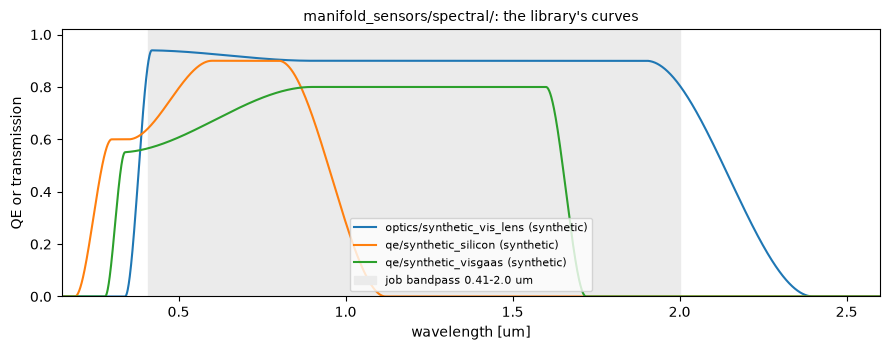

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from protodirsig.spectral import read_curve

fig, ax = plt.subplots(figsize=(9, 3.6))
for path in sorted((LIB / "spectral").glob("*/*.csv")):
    cv = read_curve(path)
    print(f"{path.relative_to(LIB)}: {cv.meta['quantity']}, provenance {cv.meta['provenance']}, "
          f"range {cv.meta['range_um']} um, {len(cv.wavelength)} rows, max {cv.value.max():.2f}")
    ax.plot(cv.wavelength, cv.value, label=f"{path.parent.name}/{path.stem} ({cv.meta['provenance']})")
ax.axvspan(0.41, 2.0, color="0.92", zorder=0, label="job bandpass 0.41-2.0 um")
ax.set_xlim(0.15, 2.6); ax.set_ylim(0, 1.02)
ax.set_xlabel("wavelength [um]"); ax.set_ylabel("QE or transmission")
ax.legend(fontsize=8, loc="lower center"); ax.set_title("manifold_sensors/spectral/: the library's curves", fontsize=10)
plt.tight_layout(); plt.show()

## What DIRSIG sees: the composed channel response

DIRSIG takes one response per channel. The generator renders each library sensor into the
template `.platform` (`manifold_config_repo/platforms/AurorNIRDetector/`). It writes the product of the
three factors as a tabulated channel on the template's 0.41–2.0 µm, 1 nm bandpass grid, with peak
QE in electrons per photon. A scalar optics throughput is not in the channel. It goes to DIRSIG's
`aperturethroughput`, so the plot multiplies it back in to show each sensor's whole spectral chain.

auror-nir                    channel 'nir-b1', shape tabulated, aperturethroughput 0.875, peak 0.875, integral 0.1397 um
deepscan-850-306-nir-1280    channel 'nir-b1', shape tabulated, aperturethroughput 0.875, peak 0.695, integral 0.1102 um


synthetic-600-200-vis-1920   channel 'vis-pan', shape tabulated, aperturethroughput 1, peak 0.834, integral 0.2392 um


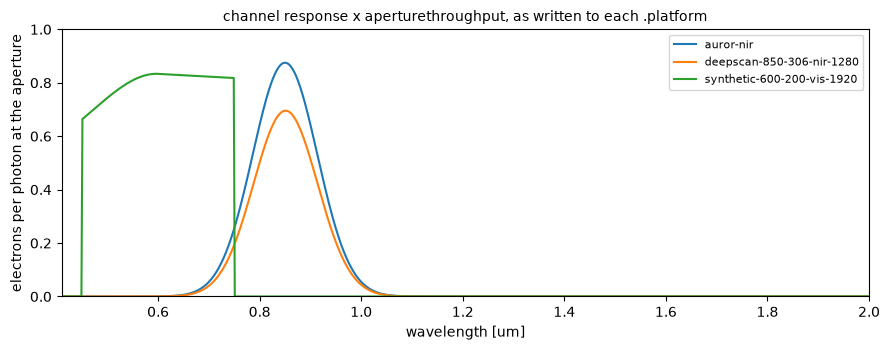

In [5]:
import lxml.etree as et
from protodirsig.platform_gen import render_platform
from protodirsig.run_spec import load_run_spec

TEMPLATE = CONFIG_REPO / "platforms" / "AurorNIRDetector" / "AurorNIRDetector.platform"
base_settings = load_run_spec(RUN_SPEC)["descriptor"]["settings"][0]
fig, ax = plt.subplots(figsize=(9, 3.6))
for name, (entry_id, doc) in SENSORS.items():
    out = render_platform(TEMPLATE, doc, entry_id, [{**base_settings, "entry_id": entry_id}], 10, LIB,
                          WORK / "platforms" / f"{entry_id}.platform")
    root = et.parse(str(out.path)).getroot()
    tau = float(root.findtext(".//properties/aperturethroughput"))
    ch = root.find(".//channellist/channel")
    wl = np.array([float(e.findtext("spectralpoint")) for e in ch.findall("entry")])
    resp = np.array([float(e.findtext("value")) for e in ch.findall("entry")])
    print(f"{entry_id:28s} channel {ch.get('name')!r}, shape {ch.get('shape')}, aperturethroughput {tau:g}, "
          f"peak {resp.max() * tau:.3f}, integral {np.trapezoid(resp * tau, wl):.4f} um")
    ax.plot(wl, resp * tau, label=entry_id)
ax.set_xlim(0.41, 2.0); ax.set_ylim(0, 1)
ax.set_xlabel("wavelength [um]"); ax.set_ylabel("electrons per photon at the aperture")
ax.legend(fontsize=8); ax.set_title("channel response x aperturethroughput, as written to each .platform", fontsize=10)
plt.tight_layout(); plt.show()

**Reading the plot.** `auror-nir` has no QE curve, so its response is a unit-peak gaussian times
the 0.875 scalar throughput. `deepscan_850_306_nir_1280` is the same optics and band with the
synthetic VisGaAs QE (0.79 at 0.85 µm) applied. The VIS camera is a 0.45–0.75 µm rectangle times
the lens curve times the silicon QE. Its edges are half-weight samples: DIRSIG's own rectangular
channel does that with an edge on a grid point (CONOPS and Guide, section 9).

`auror_ref.yaml` itself asks for `channel_response: native`, the received platform's own gaussian
channel. That channel peaks at 1/√(2π) ≈ 0.399, not 1, which is how the received AUROR_ref tree was
made. A run spec derived for a sweep is tabulated, as plotted here.

---
# Stage 1 — A run spec for each sensor

`derive_run_spec(spec, sensor_ref, entry_id, roi=…)` copies a loaded run spec and replaces only the
sensor. It sets the `descriptor.sensor` ref, the `settings` member's `entry_id`, and `meta.name`. With
`roi` it also replaces the window. It drops `channel_response`, so the derived spec is tabulated.
Exposure, frame rate, gain and black level carry over, and so does the whole `engine` section.

The cell derives two run specs from `auror_ref.yaml`: one for `auror-nir` (its own sensor, now
tabulated) and one for the synthetic VIS camera. Each gets a 32 × 32 window. It prints what differs
from the base, then writes each spec to `outputs/` and submits it.

In [6]:
from protodirsig.registry import LocalRegistry
from protodirsig.run_spec import derive_run_spec

ROI = {"Width": 32, "Height": 32, "OffsetX": None, "OffsetY": None}    # centred 32 x 32 window
base = load_run_spec(RUN_SPEC)


def changes(a, b, path=""):
    # (dotted path, base value, derived value) for every value that differs between two loaded run specs.
    if isinstance(a, dict) and isinstance(b, dict):
        return [c for k in sorted(set(a) | set(b), key=str)
                for c in changes(a.get(k), b.get(k), f"{path}.{k}" if path else str(k))]
    if isinstance(a, list) and isinstance(b, list) and len(a) == len(b):
        return [c for i, (x, y) in enumerate(zip(a, b)) for c in changes(x, y, f"{path}[{i}]")]
    return [] if a == b else [(path, a, b)]


RUNS = {}
for sensor_file in ("auror-nir.yaml", VIS_FILE):
    entry_id = SENSORS[sensor_file][0]
    spec = derive_run_spec(base, sensor_file, entry_id, roi=ROI, name=f"stage03-{entry_id}")
    path = WORK / f"{entry_id}.yaml"
    path.write_text(yaml.safe_dump(spec, sort_keys=False))
    sub = LocalRegistry().submit(path, CONFIG_REPO, WORK / entry_id, LIB)
    RUNS[entry_id] = sub
    print(f"{path.relative_to(PROJECT)}")
    for p, was, now in changes(base, spec):
        print(f"   {p:42s} {str(was):.40s}  ->  {str(now):.40s}")
    print(f"   submit: {sub.verdict.upper()}  " + ", ".join(f"{k} {'pass' if v else 'FAIL'}" for k, v in sub.checks.items()))
    for reason in sub.reasons:
        print("   -", reason)
assert all(s.accepted for s in RUNS.values())

Material [Dummy] ID has already been set to [N/A], can't override.


Material [Dummy] ID has already been set to [N/A], can't override.


outputs/stage_03_sweep/auror-nir.yaml
   descriptor.meta.name                       auror-ref-static-pose  ->  stage03-auror-nir
   descriptor.sensor.ref.content_hash         sha256:5cdfe1f87b8df604646739a6220ff39d2  ->  sha256:<hash>
   descriptor.settings[0].roi.Height          500  ->  32
   descriptor.settings[0].roi.Width           500  ->  32
   engine.platform.channel_response           native  ->  None
   submit: ACCEPTED  schema pass, resolution pass, execution pass


outputs/stage_03_sweep/synthetic-600-200-vis-1920.yaml
   descriptor.meta.name                       auror-ref-static-pose  ->  stage03-synthetic-600-200-vis-1920
   descriptor.sensor.ref.content_hash         sha256:5cdfe1f87b8df604646739a6220ff39d2  ->  sha256:<hash>
   descriptor.sensor.ref.name                 auror-nir.yaml  ->  synthetic_600_200_vis_1920.yaml
   descriptor.settings[0].entry_id            auror-nir  ->  synthetic-600-200-vis-1920
   descriptor.settings[0].roi.Height          500  ->  32
   descriptor.settings[0].roi.Width           500  ->  32
   engine.platform.channel_response           native  ->  None
   submit: ACCEPTED  schema pass, resolution pass, execution pass


Both are accepted. The changed paths are the sensor ref, the window, the entry id, the name, and
`engine.platform.channel_response` (present in the base, absent in the derived spec). The sensor
ref's `content_hash` is the placeholder `sha256:<hash>`, which the loader does not verify.
`scripts/stamp_hashes.py` would stamp it if the spec were committed under `manifold_run_specs/`, as
`manifold_run_specs/synthetic_vis.yaml` is.

---
# Stage 2 — The same scenario, two sensors

`Simulation.run()` on each accepted submission compiles the Tahoe scene and renders the 32 × 32
window. The sensor sits 550 km above the scene origin looking straight down. A pixel is 10 µm on
306 mm for `auror-nir` and 5.5 µm on 200 mm for the VIS camera, so the two windows cover different
ground: about 0.58 km and 0.48 km across.

The images are in DIRSIG's units, electrons per m² of focal plane over the 5 ms integration.
Electrons per pixel are that times the element area: 1e-10 m² and 3.0e-11 m². Each panel has its own
colour scale. The two bands see different things: VIS against NIR, different apertures, and the
lens and QE curves.

Material [Dummy] ID has already been set to [N/A], can't override.


Material [Dummy] ID has already been set to [N/A], can't override.


auror-nir                    rendered in  3.7 s -> outputs/stage_03_sweep/auror-nir/output/AurorNIROutput.img


synthetic-600-200-vis-1920   rendered in  3.7 s -> outputs/stage_03_sweep/synthetic-600-200-vis-1920/output/AurorNIROutput.img


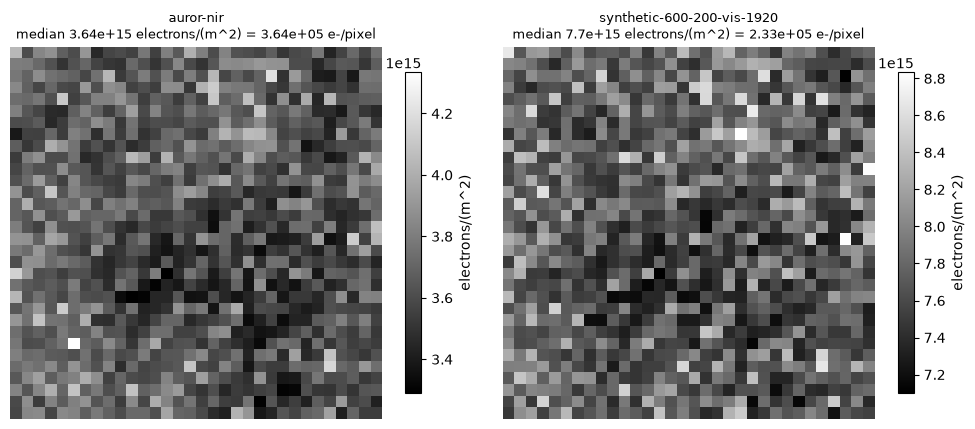

In [7]:
import time

RESULTS = {}
for entry_id, sub in RUNS.items():
    t0 = time.perf_counter()
    RESULTS[entry_id] = sub.simulation.run()
    print(f"{entry_id:28s} rendered in {time.perf_counter() - t0:4.1f} s -> "
          f"{RESULTS[entry_id].image.relative_to(PROJECT)}")


def load(result):
    hdr = Path(f"{result.image}.hdr").read_text()
    units = next(l.split("=", 1)[1].strip() for l in hdr.splitlines() if l.startswith("data units"))
    img = np.fromfile(result.image, dtype="<f8").reshape(ROI["Height"], ROI["Width"])
    truth = np.fromfile(result.truth[0], dtype="<f8").reshape(ROI["Height"], ROI["Width"], 6)
    return img, truth, units


fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
for ax, (entry_id, result) in zip(axes, RESULTS.items()):
    img, truth, units = load(result)
    pitch_m = BY_ENTRY[entry_id]["focal_planes"][0]["detector"]["SensorPixelWidth"] * 1e-6
    im = ax.imshow(img, cmap="gray")
    fig.colorbar(im, ax=ax, shrink=0.8, label=units)
    ax.set_title(f"{entry_id}\nmedian {np.median(img):.3g} {units} = {np.median(img) * pitch_m ** 2:.3g} e-/pixel",
                 fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()

Per m² of focal plane the VIS image is about twice as bright as the NIR one. Its band is wider and
its QE higher, which outweighs its slower optics (f/4 against f/3.6). Per pixel it is darker, because
a 5.5 µm pixel has 0.3 of the area of a 10 µm one.

## Ground sample distance from the geolocation truth

The template's `GeoLocation` truth gives the ECEF point each pixel's ray hit. The distance between
adjacent pixels on the ground, with the vertical component (terrain relief) projected out, should
be pitch ÷ focal length × range. The range is the platform's height from the run spec minus the
terrain height in the window, from the same truth.

In [8]:
print(f"{'sensor':28s} {'pitch/f x range':>16s} {'measured (median)':>18s} {'ratio':>7s}")
for entry_id, result in RESULTS.items():
    _, truth, _ = load(result)
    entry = BY_ENTRY[entry_id]
    pitch_m = entry["focal_planes"][0]["detector"]["SensorPixelWidth"] * 1e-6
    focal_m = entry["optics"]["focal_length"] * 1e-3
    xyz = truth[..., 3:6]
    up = xyz / np.linalg.norm(xyz, axis=-1, keepdims=True)

    def horizontal(d, u):
        return np.linalg.norm(d - (d * u).sum(-1, keepdims=True) * u, axis=-1).ravel()

    spacing = np.concatenate([horizontal(np.diff(xyz, axis=0), up[:-1]), horizontal(np.diff(xyz, axis=1), up[:, :-1])])
    height = base["engine"]["motion"]["position"]["xyz"][2]                # scene frame, origin at 0 m
    predicted = pitch_m / focal_m * (height - np.median(truth[..., 2]))
    print(f"{entry_id:28s} {predicted:14.2f} m {np.median(spacing):16.2f} m {np.median(spacing) / predicted:7.4f}")
    assert abs(np.median(spacing) / predicted - 1) < 0.01

sensor                        pitch/f x range  measured (median)   ratio
auror-nir                             17.97 m            17.98 m  1.0006
synthetic-600-200-vis-1920            15.12 m            15.19 m  1.0047


Both agree within 1 %. The library's GSD test (`tests/test_sensor_render.py`) checks the same thing
for all three sensors in a 16 × 16 window.

---
# What is synthetic and what is not

**Synthetic, invented for pipeline development (not vendor data, not measured):**

* all three spectral curves: `qe/synthetic_visgaas.csv`, `qe/synthetic_silicon.csv`,
  `optics/synthetic_vis_lens.csv` (`provenance: synthetic` in each file);
* the whole `synthetic_600_200_vis_1920` camera: aperture, focal length, 1920 × 1080 array, 5.5 µm
  pitch, band, readout;
* the DeepScan entry's QE, until the Teledyne SCION curve is imported.

**Carried from the received AUROR_ref tree:** the `auror-nir` optics (85 mm, 306 mm, 0.875
throughput), 10 µm pitch and gaussian 0.85 µm / 0.15 µm channel, the scene, atmosphere database,
weather, platform position, epoch and seed. The atmosphere database was built for western New York,
not Tahoe (CONOPS and Guide, section 9), so these electron counts are not Tahoe's.

**From vendor material:** DeepScan's detector block (Teledyne SCION family, 1280 × 1024, 10 µm
pitch, VisGaAs 0.3–1.7 µm). Its other values are copied from `auror-nir` and are listed in the
BACKLOG for confirmation.

**Measured here, on this DIRSIG install:** the generator's conventions against DIRSIG itself. These
are units, the native-channel factors, the window offset, the ground sample distance, and the
absolute electron count against an analytic Lambertian-plane value. That last check agrees to 1e-4
(`tests/test_absolute_radiometry.py`; CONOPS and Guide, section 9). It establishes that the sensor
chain is computed as stated. It does not make the synthetic curves real.